In [17]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [18]:
df = pd.read_csv(Path('movies_metadata.csv'))
df.head()

,budget,id,release_date,revenue,runtime,title,rating,vote_count,genre
0,3500000,651,1/24/1970,81600000,116.0,M*A*S*H,6.9,238,Comedy
1,12000000,11202,1/25/1970,89800000,172.0,Patton,7.3,327,Drama
2,25485000,11165,1/26/1970,29548291,144.0,Tora! Tora! Tora!,6.9,150,History
3,11000000,42345,1/27/1970,2200000,124.0,The Molly Maguires,5.9,16,Drama
4,7000000,2998,2/9/1970,1000000,113.0,Zabriskie Point,7.1,78,Drama


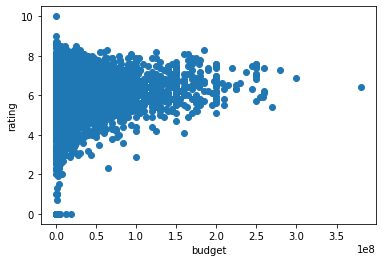

In [19]:
plt.scatter(df.budget, df.rating)
plt.xlabel('budget')
plt.ylabel('rating')
plt.show()

In [20]:
X = df.budget.values.reshape(-1, 1)

In [21]:
X[:5]

array([[ 3500000],
       [12000000],
       [25485000],
       [11000000],
       [ 7000000]], dtype=int64)

In [22]:
X.shape

(6265, 1)

In [23]:
y = df.rating 

In [24]:
model = LinearRegression()

In [25]:
model.fit(X, y)

LinearRegression()

In [26]:
y_pred = model.predict(X)

In [27]:
print(y_pred.shape)

(6265,)


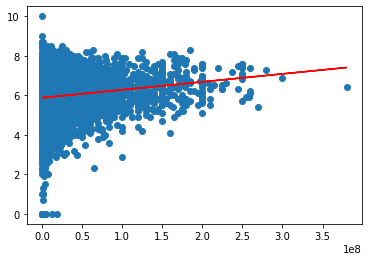

In [28]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.show()

In [29]:
print(model.coef_)
print(model.intercept_)

[4.02419381e-09]
5.877290289951715


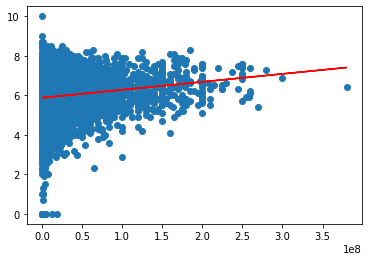

In [30]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.show()

In [31]:
print(model.coef_)
print(model.intercept_)

[4.02419381e-09]
5.877290289951715


In [ ]:
#test two



In [50]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(solver='lbfgs',
                                max_iter=200,
                                random_state=1)

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [ ]:
#test three

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [33]:
movies_df = pd.read_csv('movies_metadata.csv')

In [34]:
# Select budget as the independent variable (x) and average rating as the dependent variable (y)
X = movies_df['budget'].values.reshape(-1, 1)
y = movies_df['rating'].values

In [35]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Create a Standard Scaler object
scaler = StandardScaler()

In [37]:
# Fit the scaler to the training data
scaler.fit(X_train)

StandardScaler()

In [38]:
# Scale the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Create a Linear Regression model
lr_model = LinearRegression()

In [40]:
# Fit the model to the scaled training data
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [41]:
# Use the model to make predictions on the scaled testing data
y_pred = lr_model.predict(X_test_scaled)

In [42]:
from sklearn.metrics import r2_score

# Calculate the R-squared value of the model
r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.004944490116949085


In [43]:

# Print the first 10 actual and predicted values of average rating
print("Actual\tPredicted")
for i in range(10):
    print("{:.2f}\t{:.2f}".format(y_test[i], y_pred[i]))

Actual	Predicted
4.00	5.86
6.80	5.87
7.00	6.27
4.20	5.87
7.80	5.86
5.40	6.17
5.90	5.99
7.40	5.93
6.30	6.21
4.80	5.87


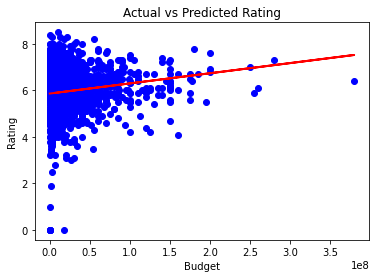

In [45]:
# Create a scatter plot with the actual and predicted values
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.title('Actual vs Predicted Rating')
plt.xlabel('Budget')
plt.ylabel('Rating')
plt.show()